# Parameter-Free Fidelity: Area Under the Risk-Coverage Curve (AURC)
This notebook implements the exact fix for the hyperparameter / gauge-invariance vulnerability by evaluating Area Under the Fidelity-Coverage curve.


In [1]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.datasets import make_moons, make_circles
from sklearn.neural_network import MLPClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import auc

sns.set_theme(style="whitegrid", context="paper")


### Generating Synthetic Benchmark


In [2]:
X, y = make_moons(n_samples=3000, noise=0.3, random_state=42)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.4, random_state=42)

teacher = MLPClassifier(hidden_layer_sizes=(64, 64), max_iter=1000, random_state=1).fit(X_train, y_train)
p_teacher = teacher.predict_proba(X_test)[:, 1]
h_teacher = teacher.predict(X_test)

s_lr = LogisticRegression().fit(X_train, teacher.predict(X_train))
s_dt = DecisionTreeClassifier(max_depth=3, random_state=42).fit(X_train, teacher.predict(X_train))
h_lr = s_lr.predict(X_test)
h_dt = s_dt.predict(X_test)


### AURC Calculation


In [3]:
margins = np.abs(p_teacher - 0.5)
sorted_indices = np.argsort(margins)

h_teacher_sorted = h_teacher[sorted_indices]
h_lr_sorted = h_lr[sorted_indices]
h_dt_sorted = h_dt[sorted_indices]

coverages = np.linspace(0.05, 1.0, 50)
fid_lr_curve = []
fid_dt_curve = []

for c in coverages:
    n_points = max(1, int(c * len(sorted_indices)))
    fid_lr_curve.append(np.mean(h_teacher_sorted[:n_points] == h_lr_sorted[:n_points]))
    fid_dt_curve.append(np.mean(h_teacher_sorted[:n_points] == h_dt_sorted[:n_points]))
    
aurc_lr = auc(coverages, fid_lr_curve) / (1.0 - 0.05)
aurc_dt = auc(coverages, fid_dt_curve) / (1.0 - 0.05)


### Plotting the Parameter-Free Curve


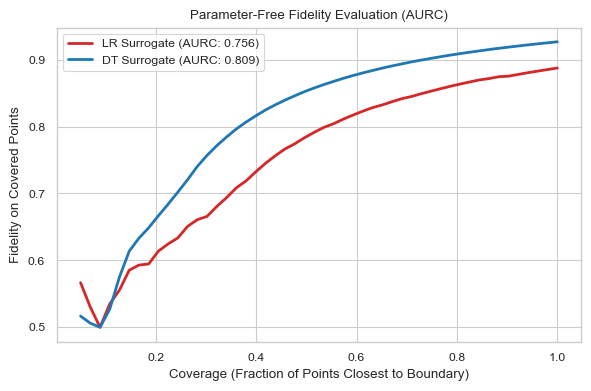

In [4]:
plt.figure(figsize=(6, 4))
plt.plot(coverages, fid_lr_curve, label=f"LR Surrogate (AURC: {aurc_lr:.3f})", lw=2, color='tab:red')
plt.plot(coverages, fid_dt_curve, label=f"DT Surrogate (AURC: {aurc_dt:.3f})", lw=2, color='tab:blue')
plt.xlabel("Coverage (Fraction of Points Closest to Boundary)")
plt.ylabel("Fidelity on Covered Points")
plt.title("Parameter-Free Fidelity Evaluation (AURC)")
plt.legend()
plt.tight_layout()
plt.savefig("../figures/aurc_evaluation.pdf")
plt.show()
